# Rigorous Optimization

## Introduction

We have already used some optimizations implicitly in several parts of implementation. Most of them are simple enough to be completed in several seconds. Although such simple optimizations can provide useful results for easy cases, they are not powerful enough for many other cases where component peaks are not visible.

For those hard-to-analyze cases, the problem gets underdetermined, meaning there are so many possible solutions that we are not sure which one is appropriate. 

However, we can utilize SEC and SAXS theories to reduce the solution space. More concretely, we can add constraints based on the theories. For example, in plain words, 

* Larger particles elute faster than smaller ones,
* Peaks broaden as they stay longer in the column,
* Reconstructed Rg curve should be consistent with observed Rg curve.

We can impose these constraints by adding parameters, using advanced models and adopting global optimization methods.

In this chapter, we will show how to use such rigorous optimizations leaving the detailed discussion elsewhere.

## How to get initial parameters

For the global optimization, the standard way of preparing initial parameters is one of the following.

* EGH: decomposition = ssd.quick_decomposition(proportions=[...])
* SDM: sdm_decomposition = decomposition.upgrade(model='SDM')
* EDM: edm_decomposition = decomposition.upgrade(model='EDM')

For EGH, the default decomposition, preferably with proportions option, suffices.
For other advanced models, use the EGH decomposition to get respective model parameters with optimizw_with_model method.

## EGH Quick Decomposition

Note that we have included the rgcurve here because it is required later for the rigorous optimization. 

  0%|          | 0/203 [00:00<?, ?it/s]

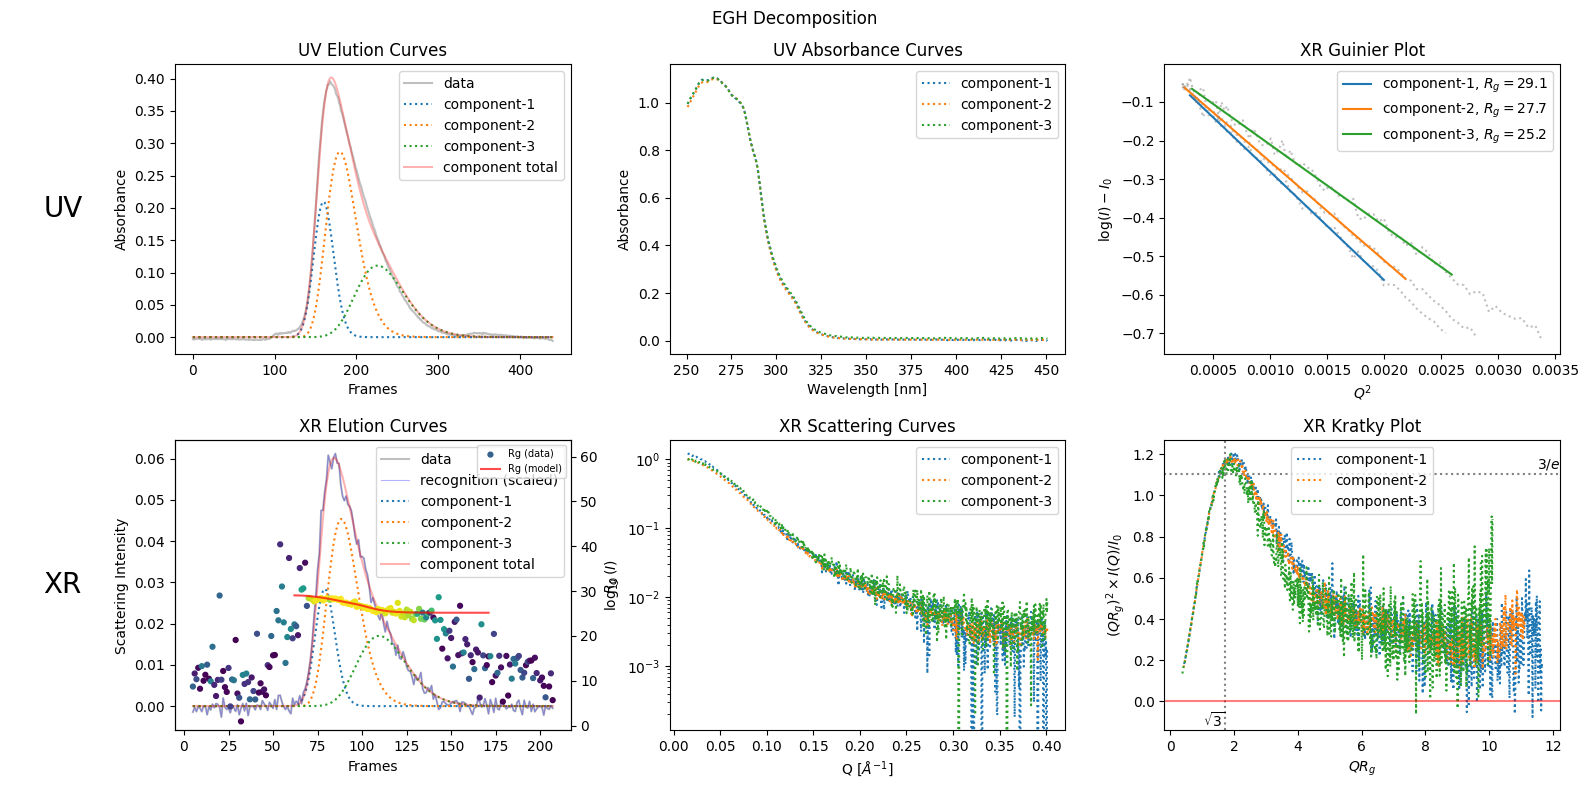

In [1]:
from molass import get_version
assert get_version() >= '1.0.1', "this notebook requires molass v1.0.1 or higher."
from molass_data import SAMPLE4
from molass.DataObjects import SecSaxsData as SSD
ssd = SSD(SAMPLE4)
trimmed_ssd = ssd.trimmed_copy()
corrected_ssd = trimmed_ssd.corrected_copy()
decomposition = corrected_ssd.quick_decomposition(proportions=[0.2, 0.5, 0.3])
rgcurve = corrected_ssd.xr.compute_rgcurve()
plot6 = decomposition.plot_components(title="EGH Decomposition", rgcurve=rgcurve)

## EGH Rigorous Optimization

In [2]:
run_info = decomposition.optimize_rigorously(rgcurve=rgcurve, analysis_folder="temp_analysis_egh", method='DE', niter=20)

C:\Users\takahashi\AppData\Local\Temp\ipykernel_21828\431044095.py:1: UserWarning: optimize_rigorously() is running on corrected data (Pattern A). The recommended approach is to pass trimmed_ssd=<your trimmed SSD> (Pattern B), which lets the optimizer fit the baseline as a free parameter on uncorrected data. This is safe to ignore, but may produce a suboptimal initial baseline if the LPM correction is biased.
  run_info = decomposition.optimize_rigorously(rgcurve=rgcurve, analysis_folder="temp_analysis_egh", method='DE', niter=20)


[DEBUG] UV scale refinement disabled (hasattr=False, _refine_uv_scales=None)


In [3]:
# Load best result available so far (waits if no results yet; safe to re-run)
result = run_info.load_best()
print(f"Best result SV: {result.sv:.1f}")

Loading rigorous result from job: 000
Best result SV: 81.8


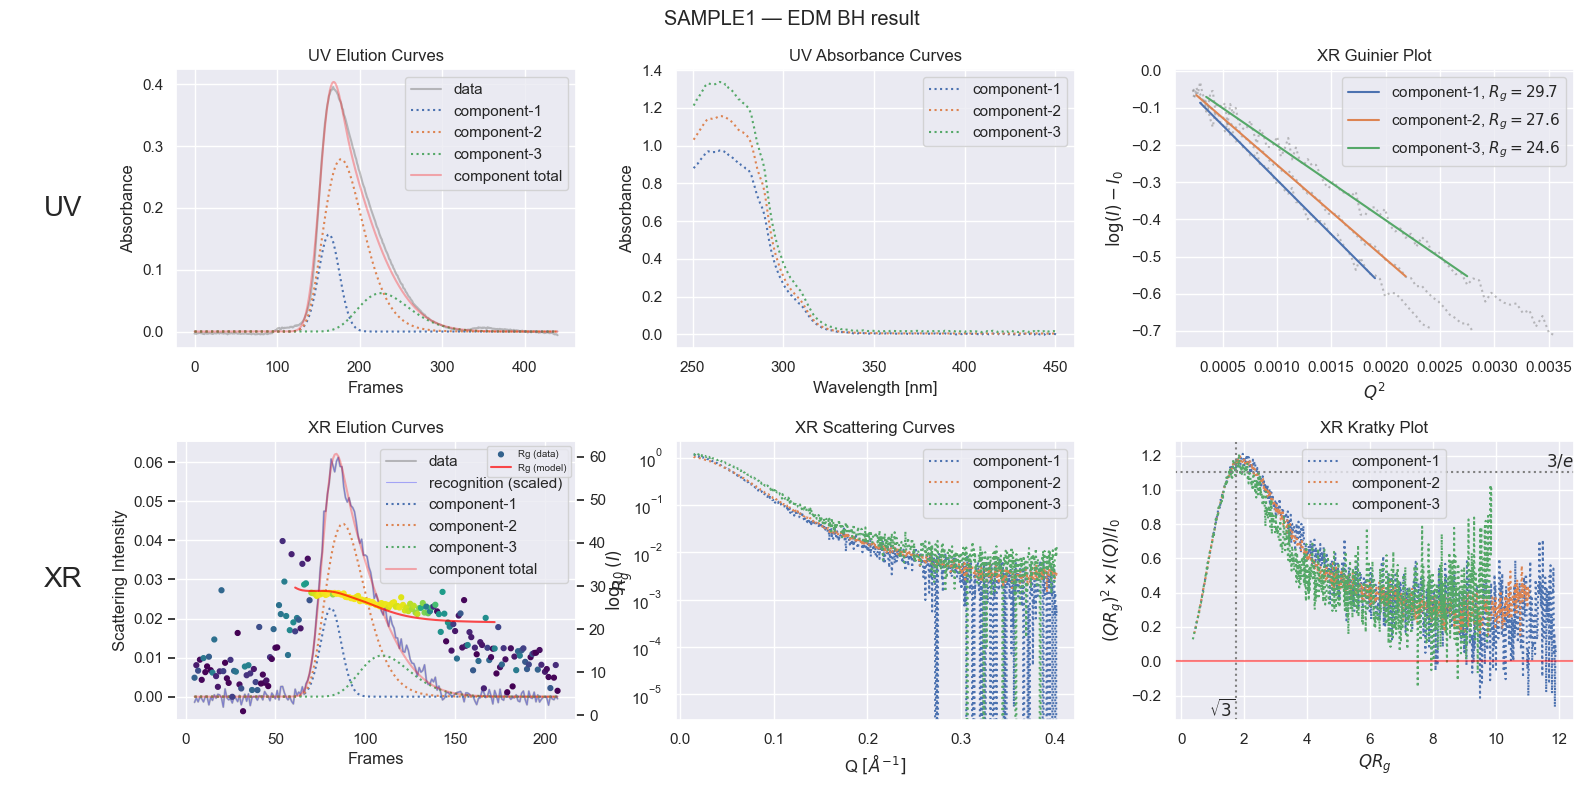

In [4]:
# Visual comparison: rigorous result components vs data
result.plot_components(title="SAMPLE1 — EDM BH result", rgcurve=rgcurve)

```{figure} ../../_static/images/rigorous-egh.png
:name: rigorous-egh

Rigorous Optimization (EGH)
```

For more information, see [Molass Technical Report](https://biosaxs-dev.github.io/molass-technical/).